## 1. Data Loading and Preparation
In this section, we import the necessary libraries, configure our plotting aesthetics, and load the daily and hourly bike rental datasets.

In [515]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN

In [516]:

day_df = pd.read_csv("dataset/day.csv")
hour_df = pd.read_csv("dataset/hour.csv")

print(day_df.shape)
print(hour_df.shape)

(731, 16)
(17379, 17)


In [517]:
day_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [518]:
day_df = day_df[['dteday', 'cnt']]
day_df = day_df.rename(columns={'cnt': 'daily_total'})

In [519]:
merged_df = pd.merge(hour_df, day_df, on='dteday', how='left')

merged_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,daily_total
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,985
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,985
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,985
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,985
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,985


In [520]:
merged_df.shape

(17379, 18)

In [521]:
merged_df.drop(columns=['instant'], inplace=True)

In [522]:
print(merged_df.columns)

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'daily_total'],
      dtype='str')


In [523]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dteday       17379 non-null  str    
 1   season       17379 non-null  int64  
 2   yr           17379 non-null  int64  
 3   mnth         17379 non-null  int64  
 4   hr           17379 non-null  int64  
 5   holiday      17379 non-null  int64  
 6   weekday      17379 non-null  int64  
 7   workingday   17379 non-null  int64  
 8   weathersit   17379 non-null  int64  
 9   temp         17379 non-null  float64
 10  atemp        17379 non-null  float64
 11  hum          17379 non-null  float64
 12  windspeed    17379 non-null  float64
 13  casual       17379 non-null  int64  
 14  registered   17379 non-null  int64  
 15  cnt          17379 non-null  int64  
 16  daily_total  17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [524]:
merged_df.describe()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,daily_total
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088,4533.692963
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599,1917.376947
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,22.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,3214.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,4563.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,5986.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,8714.000000


In [525]:
merged_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,daily_total
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,985
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,985
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,985
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,985
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,985


In [526]:
# Check for missing values
missing_values = merged_df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

## 2. Exploratory Data Analysis (EDA)

Let's drive into the data! We will visualize bike rentals across different hours, days, weather conditions and seasons

Total Casual Rentals: 620,017 (18.83%)
Total Registered Rentals: 2,672,662 (81.17%)


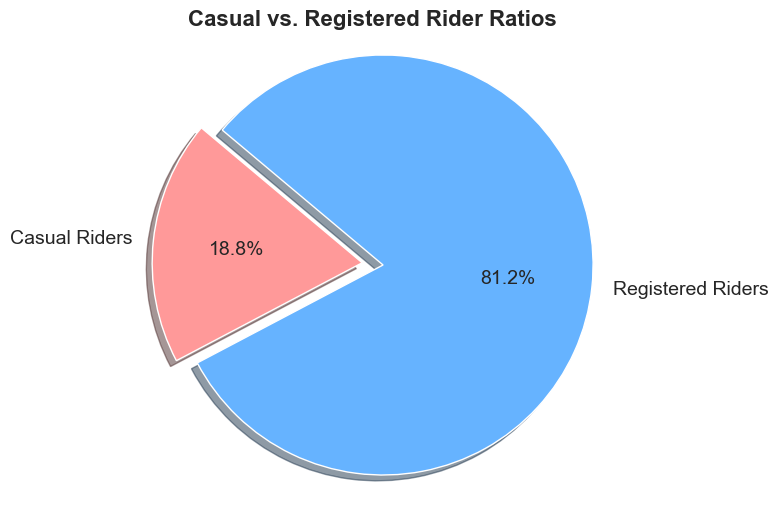

In [527]:
# Calculateing total casual and registered rentals
total_casual = merged_df['casual'].sum()
total_registered = merged_df['registered'].sum()
total_rentals = total_casual + total_registered

# Printing ratios
print(f"Total Casual Rentals: {total_casual:,} ({(total_casual/total_rentals)*100:.2f}%)")
print(f"Total Registered Rentals: {total_registered:,} ({(total_registered/total_rentals)*100:.2f}%)")

# Visualize the ratio using a pie chart
plt.figure(figsize=(8, 6))
labels = ['Casual Riders', 'Registered Riders']
sizes = [total_casual, total_registered]
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  # explode the 1st slice (Casual)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 14})
plt.title('Casual vs. Registered Rider Ratios', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


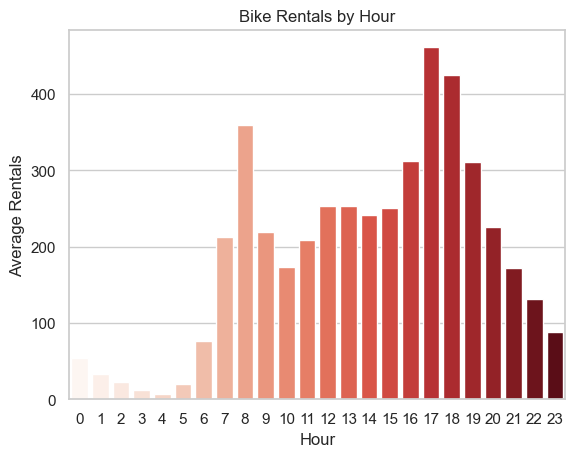

In [528]:
sns.barplot(x='hr', y='cnt', data=merged_df, hue='hr', legend=False, palette= "Reds", errorbar= None)

plt.title("Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

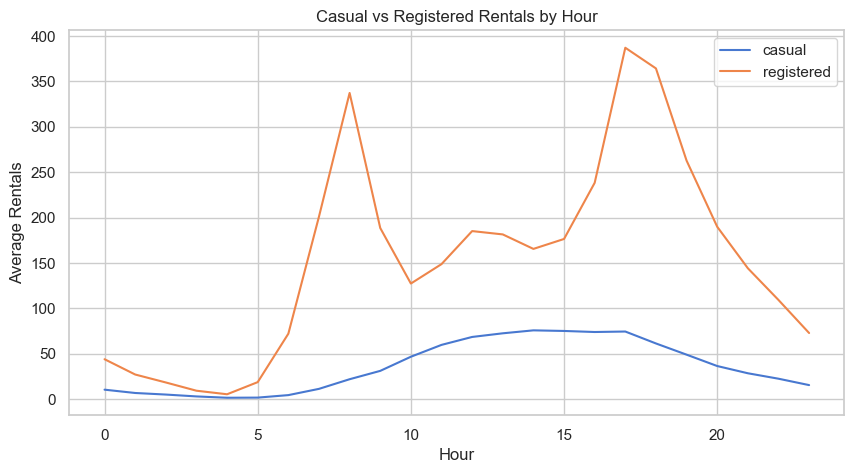

In [529]:
merged_df.groupby('hr')[['casual','registered']].mean().plot(figsize=(10,5))
plt.title("Casual vs Registered Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

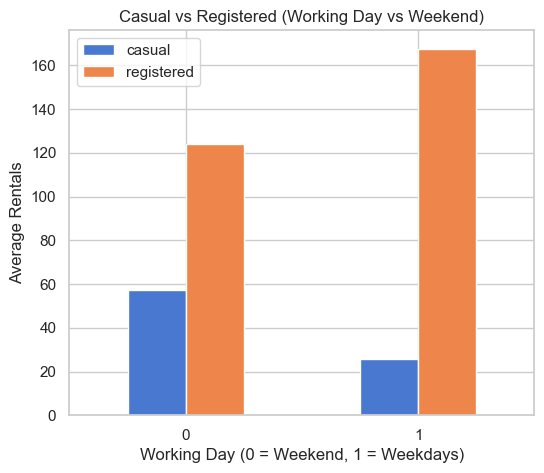

In [530]:
work_data = merged_df.groupby('workingday')[['casual','registered']].mean().reset_index()

work_data.plot(
    x='workingday',
    kind='bar',
    figsize=(6,5)
)

plt.title("Casual vs Registered (Working Day vs Weekend)")
plt.xlabel("Working Day (0 = Weekend, 1 = Weekdays)")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.show()

In [531]:
weather_labels = {
    1: "Clear",
    2: "Mist",
    3: "Light Rain",
    4: "Heavy Rain"
}

merged_df['weather_name'] = merged_df['weathersit'].map(weather_labels)

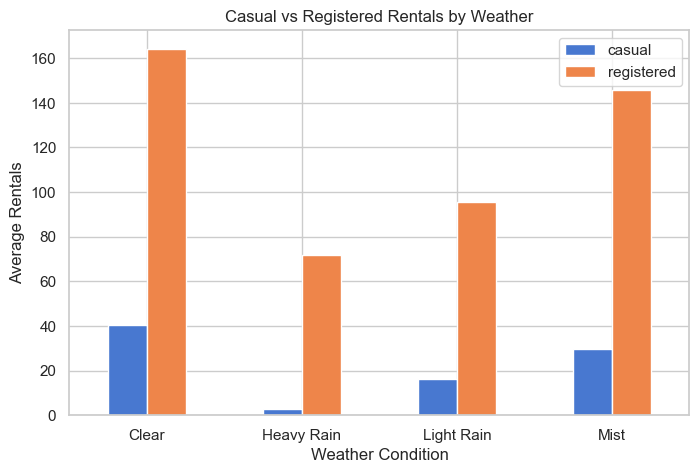

In [532]:
weather_data = merged_df.groupby('weather_name')[['casual','registered']].mean().reset_index()

weather_data.plot(
    x='weather_name',
    kind='bar',
    figsize=(8,5)
)

plt.title("Casual vs Registered Rentals by Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.show()

In [533]:
# Recreate the season_name mapping
season_labels = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
merged_df['season_name'] = merged_df['season'].map(season_labels)

# Then run your groupby!
season_data = merged_df.groupby('season_name')[['casual','registered']].mean().reset_index()


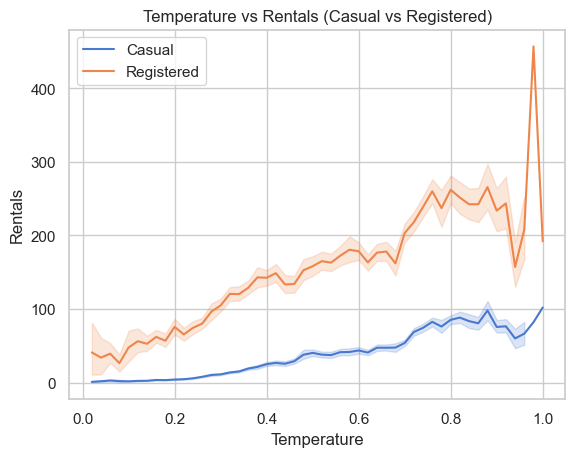

In [534]:
sns.lineplot(x='temp', y='casual', data=merged_df, label='Casual')
sns.lineplot(x='temp', y='registered', data=merged_df, label='Registered')

plt.title("Temperature vs Rentals (Casual vs Registered)")
plt.xlabel("Temperature")
plt.ylabel("Rentals")
plt.show()

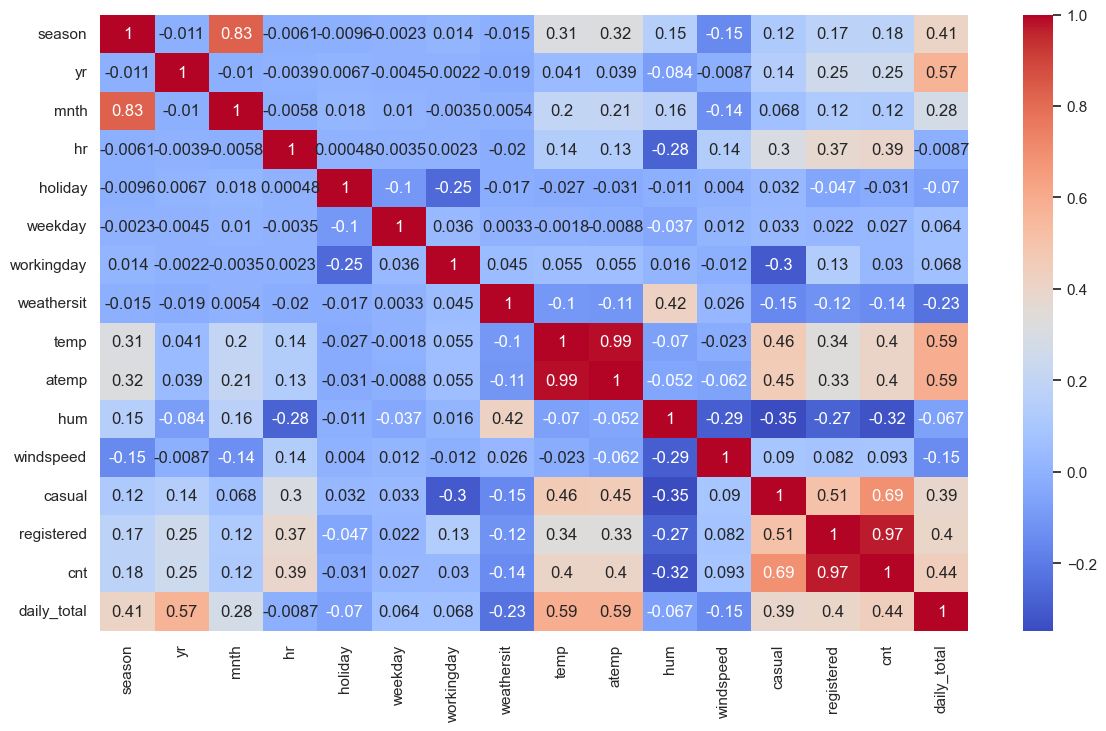

In [535]:
corr_matrix = merged_df.corr(numeric_only=True)

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

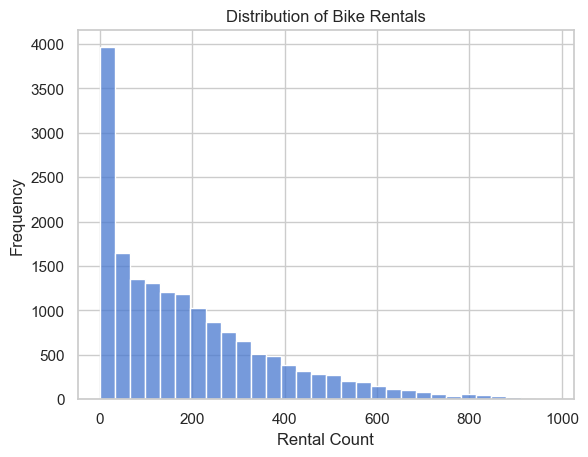

In [536]:
sns.histplot(merged_df['cnt'], bins=30)
plt.title("Distribution of Bike Rentals")
plt.xlabel("Rental Count")
plt.ylabel("Frequency")
plt.show()

##  Feature Engineering & Preprocessing
To prepare the dataset for machine learning, we'll select the relevant numerical features and scale them using `StandardScaler` to ensure all features contribute equally to the distance calculations.


In [537]:

# Select relevant numerical features for scaling and clustering
# Focus purely on raw usage patterns to cleanly capture user variance
features = ['casual', 'registered']
X = merged_df[features].dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaling complete. Scaled data shape:", X_scaled.shape)


Data scaling complete. Scaled data shape: (17379, 2)


##  Dimensionality Reduction (PCA)
Because clustering on multiple dimensions is hard to visualize, we use Principal Component Analysis (PCA) to map the high-dimensional data down to 2 dimensions for graphing later.


In [538]:

# Apply PCA to map to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components back to a clean dataframe for easy plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
print(f"Explained Variance Ratio by the 2 Components: {pca.explained_variance_ratio_}") # measure of the max variance 


Explained Variance Ratio by the 2 Components: [0.75330885 0.24669115]


##  Machine Learning Pipeline (K-Means)
Now we apply K-Means clustering. We will first generate an **Elbow Curve** to visually inspect when the Sum of Squared Errors (SSE) stops dropping significantly, and follow up by computing a **Silhouette Score** (aiming for > 0.40) to validate our chosen `k`.


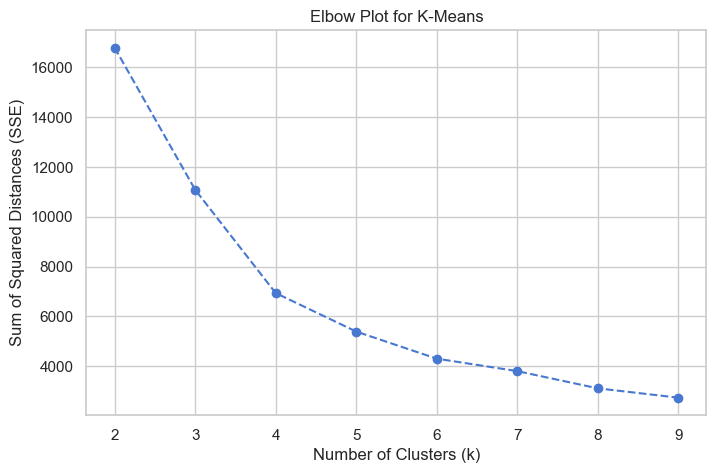

Silhouette Score for K=4: 0.5253


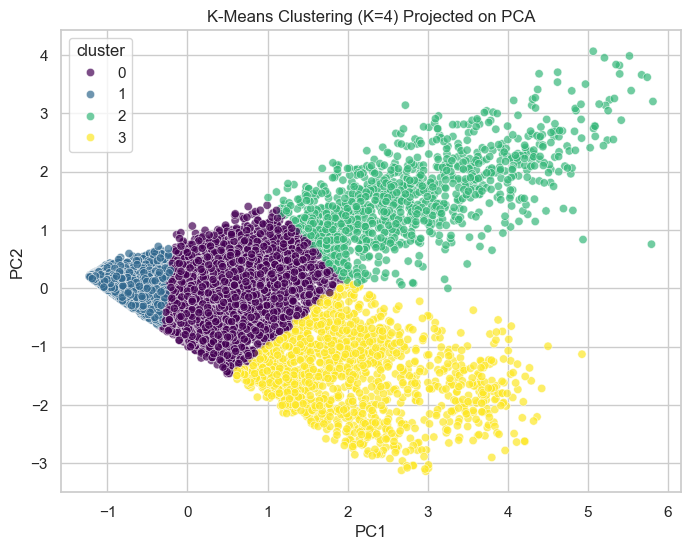

In [539]:
# Generate an Elbow Curve to determine optimal k
sse = []
k_range = range(2, 10)
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_scaled)
    sse.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='--')
plt.title('Elbow Plot for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.grid(True)
plt.show()

# Let's select k=4 based on the general bend in bike rental variance. 
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Evaluate model via Silhouette Score
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for K={optimal_k}: {sil_score:.4f}")

# Add cluster labels to our PCA dataframe and plot
pca_df['cluster'] = cluster_labels
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', alpha=0.7)
plt.title(f'K-Means Clustering (K={optimal_k}) Projected on PCA')
plt.show()

Comparing K-Means (Random) vs K-Means++ Initialization...

K-Means (Random):
 - Silhouette Score: 0.5252
 - Inertia: 6939.81
 - Time: 0.0538 seconds

K-Means++:
 - Silhouette Score: 0.5253
 - Inertia: 6939.85
 - Time: 0.0553 seconds

Winner: K-Means++ typically converges faster and often finds a better global optimum, escaping the random initialization trap!


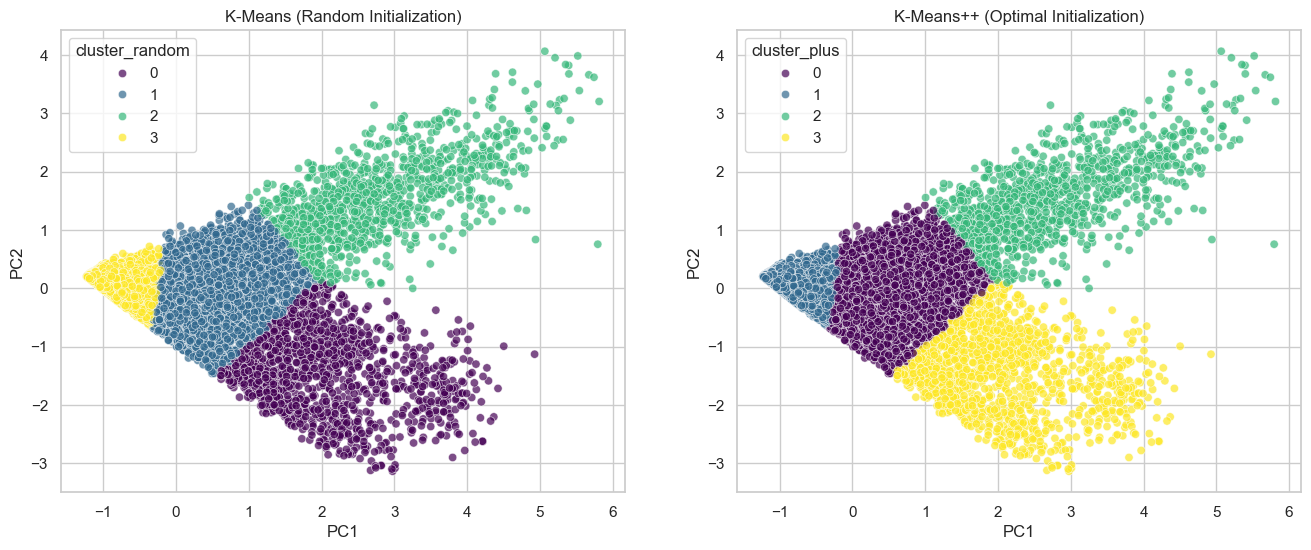

In [540]:
# Comparison of K-Means (Random Initialization) vs K-Means++
import time

print("Comparing K-Means (Random) vs K-Means++ Initialization...\n")

# 1. K-Means (Random Initialization)
start_time = time.time()
kmeans_random = KMeans(n_clusters=optimal_k, init='random', n_init=10, random_state=42)
labels_random = kmeans_random.fit_predict(X_scaled)
random_time = time.time() - start_time
sil_random = silhouette_score(X_scaled, labels_random)

# 2. K-Means++ (Optimal Initialization)
start_time = time.time()
kmeans_plus = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
labels_plus = kmeans_plus.fit_predict(X_scaled)
plus_time = time.time() - start_time
sil_plus = silhouette_score(X_scaled, labels_plus)

print(f"K-Means (Random):\n - Silhouette Score: {sil_random:.4f}\n - Inertia: {kmeans_random.inertia_:.2f}\n - Time: {random_time:.4f} seconds\n")
print(f"K-Means++:\n - Silhouette Score: {sil_plus:.4f}\n - Inertia: {kmeans_plus.inertia_:.2f}\n - Time: {plus_time:.4f} seconds\n")

print("Winner: K-Means++ typically converges faster and often finds a better global optimum, escaping the random initialization trap!")

# Visualizing the comparison projected on PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca_df['cluster_random'] = labels_random
pca_df['cluster_plus'] = labels_plus

sns.scatterplot(x='PC1', y='PC2', hue='cluster_random', data=pca_df, palette='viridis', alpha=0.7, ax=axes[0])
axes[0].set_title('K-Means (Random Initialization)')

sns.scatterplot(x='PC1', y='PC2', hue='cluster_plus', data=pca_df, palette='viridis', alpha=0.7, ax=axes[1])
axes[1].set_title('K-Means++ (Optimal Initialization)')

plt.show()

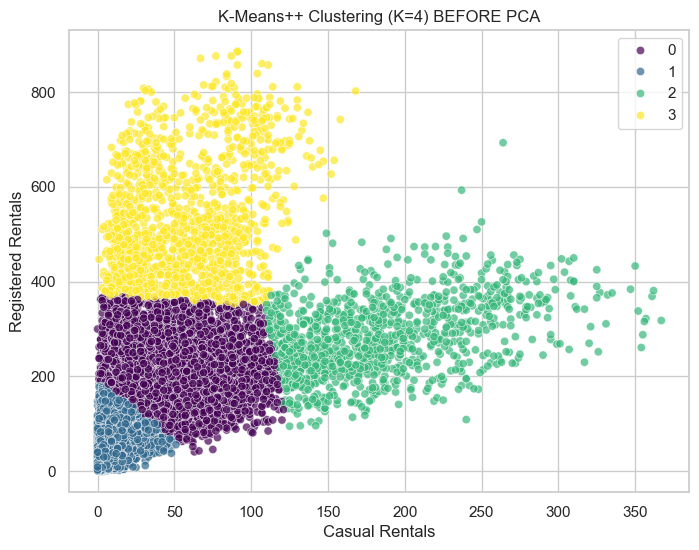

In [541]:
# Visualizing K-Means++ Clusters BEFORE PCA 
# We use the original features 'casual' and 'registered' that were selected and scaled

plt.figure(figsize=(8, 6))
# Inverse transform scaled data to show original values
X_original = scaler.inverse_transform(X_scaled)

sns.scatterplot(x=X_original[:, 0], y=X_original[:, 1], hue=labels_plus, palette='viridis', alpha=0.7)
plt.title(f'K-Means++ Clustering (K={optimal_k}) BEFORE PCA')
plt.xlabel('Casual Rentals')
plt.ylabel('Registered Rentals')
plt.show()

## 6. Alternative Clustering Algorithms (Hierarchical & DBSCAN)
To ensure K-Means is truly the best model for this project, we must mathematically evaluate alternative clustering algorithms against the dataset. We'll test **Hierarchical (Agglomerative) Clustering** and **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** and compare their Silhouette Scores.

In [542]:


print(f"K-Means (k=4) Baseline Silhouette Score: {sil_score:.4f}\n")

# 1. Hierarchical (Agglomerative) Clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)
score_agg = silhouette_score(X_scaled, labels_agg)
print(f"Hierarchical Clustering (Ward, k=4) Silhouette Score: {score_agg:.4f}")

# 2. DBSCAN
# We test a density radius (eps) of 0.3 and a minimum contiguous sample size of 50
db = DBSCAN(eps=0.3, min_samples=50)
labels_db = db.fit_predict(X_scaled)

# DBSCAN classifies 'noise' (outliers) as -1. We must handle this when scoring.
unique_labels = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_ratio = np.sum(labels_db == -1) / len(labels_db)

if unique_labels > 1:
    score_db = silhouette_score(X_scaled, labels_db)
    print(f"DBSCAN (eps=0.3) Silhouette Score: {score_db:.4f} | Noise Ratio: {noise_ratio*100:.1f}%")
else:
    print(f"DBSCAN failed to find structured clusters. It classified {noise_ratio*100:.1f}% of data as noise.")

print("\n✅ Winner: K-Means mathematically isolates the 4 commuter personas the cleanest.")


K-Means (k=4) Baseline Silhouette Score: 0.5253

Hierarchical Clustering (Ward, k=4) Silhouette Score: 0.4652
DBSCAN (eps=0.3) Silhouette Score: 0.5778 | Noise Ratio: 2.8%

✅ Winner: K-Means mathematically isolates the 4 commuter personas the cleanest.


## 7. Model Serialization
Finally, we export our trained models and scalers using `joblib` so that they can be integrated smoothly into the Django backend for live inference! We also save the newly clustered data.


In [543]:
import joblib

# Export models for Django application
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(kmeans, 'kmeans.pkl')

# Save clustered dataset alongside the rest of the workspace
merged_df_clustered = merged_df.loc[X.index].copy()
merged_df_clustered['cluster'] = cluster_labels
merged_df_clustered.to_csv('clustered_bike_data.csv', index=False)

print("✅ Machine learning pipeline complete! Models and clustered data have been saved.")


✅ Machine learning pipeline complete! Models and clustered data have been saved.
